# Support Vector Machine (SVM)

In this module, we will use Support Vector Machines to recognize
handwritten English alphabets.

We will use a real-world Kaggle Letter Recognition dataset.

## Machine Learning Problem

Input:

Numerical features extracted from handwritten letters

Output:

One of 26 English alphabet classes

A → Class A
B → Class B
C → Class C
...
Z → Class Z

## Models

We will train:

1. Linear SVM
2. RBF Kernel SVM

We will then compare their performance.

## Workflow

Dataset
↓
Data Exploration
↓
Train/Test Split
↓
Feature Scaling
↓
Linear SVM
↓
RBF SVM
↓
Predictions
↓
Evaluation
↓
Hyperparameter Tuning

#Install Kaggle

In [1]:
!pip install -q kaggle

#Import Libraries

In [2]:
import os
from getpass import getpass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


#Kaggle API Authentication

## Kaggle API Authentication

We will use `getpass()` to securely enter the Kaggle API token.

The token will not be displayed while entering it.

In [3]:
kaggle_token = getpass("Enter your Kaggle API token: ")

os.environ["KAGGLE_API_TOKEN"] = kaggle_token

del kaggle_token

print("Kaggle API token configured successfully.")

Enter your Kaggle API token: ··········
Kaggle API token configured successfully.


## Download the Letter Recognition Dataset

Kaggle Dataset:

`nishan192/letterrecognition-using-svm`

We will download and extract the dataset directly into Google Colab.

In [4]:
!mkdir -p /content/letter_recognition_dataset

!kaggle datasets download \
    -d nishan192/letterrecognition-using-svm \
    -p /content/letter_recognition_dataset \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/nishan192/letterrecognition-using-svm
License(s): unknown
100% 214k/214k [00:00<00:00, 88.1MB/s]



#Check Downloaded Files

In [5]:
os.listdir("/content/letter_recognition_dataset")

['letter-recognition.csv']

#Find CSV Files

In [6]:
csv_files = [
    file
    for file in os.listdir("/content/letter_recognition_dataset")
    if file.lower().endswith(".csv")
]

csv_files

['letter-recognition.csv']

#Load Dataset

In [7]:
dataset_path = os.path.join(
    "/content/letter_recognition_dataset",
    csv_files[0]
)

df = pd.read_csv(dataset_path)

df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


#Dataset Shape

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 20000
Columns: 17


#Column Names

In [9]:
print("Columns:")

for column in df.columns:
    print(column)

Columns:
letter
xbox 
ybox 
width 
height
onpix 
xbar 
ybar 
x2bar
y2bar 
xybar 
x2ybar
xy2bar
xedge 
xedgey
yedge 
yedgex


#Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


#Statistical Summary

In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
letter,20000,26,U,813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xbox,20000.0,NaN,NaN,NaN,4.02355,1.913212,0.0,3.0,4.0,5.0,15.0
ybox,20000.0,NaN,NaN,NaN,7.0355,3.304555,0.0,5.0,7.0,9.0,15.0
width,20000.0,NaN,NaN,NaN,5.12185,2.014573,0.0,4.0,5.0,6.0,15.0
height,20000.0,NaN,NaN,NaN,5.37245,2.26139,0.0,4.0,6.0,7.0,15.0
onpix,20000.0,NaN,NaN,NaN,3.50585,2.190458,0.0,2.0,3.0,5.0,15.0
xbar,20000.0,NaN,NaN,NaN,6.8976,2.026035,0.0,6.0,7.0,8.0,15.0
ybar,20000.0,NaN,NaN,NaN,7.50045,2.325354,0.0,6.0,7.0,9.0,15.0
x2bar,20000.0,NaN,NaN,NaN,4.6286,2.699968,0.0,3.0,4.0,6.0,15.0
y2bar,20000.0,NaN,NaN,NaN,5.17865,2.380823,0.0,4.0,5.0,7.0,15.0


## Missing Values

Before training the SVM, we need to make sure that the dataset
does not contain missing values.

In [12]:
missing_values = df.isnull().sum()

missing_values[
    missing_values > 0
]

,0


#Check Duplicate Rows

In [13]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 1332


# Target Variable

The target represents the handwritten alphabet.

The problem contains 26 classes:

A, B, C, ..., Z

Therefore, this is a:

**Multiclass Classification Problem**

Our SVM will learn boundaries that separate the different alphabet classes.

In [14]:
print(df.columns.tolist())

['letter', 'xbox ', 'ybox ', 'width ', 'height', 'onpix ', 'xbar ', 'ybar ', 'x2bar', 'y2bar ', 'xybar ', 'x2ybar', 'xy2bar', 'xedge ', 'xedgey', 'yedge ', 'yedgex']


#Inspect Target

In [15]:
df["letter"].head()

,letter
0,T
1,I
2,D
3,N
4,G


#Number of Classes

In [16]:
print(
    "Number of classes:",
    df["letter"].nunique()
)

Number of classes: 26


#List All Classes

In [17]:
classes = sorted(
    df["letter"].unique()
)

print(classes)

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


#Class Distribution

In [18]:
class_counts = (
    df["letter"]
    .value_counts()
    .sort_index()
)

class_counts

,count
letter,
A,789
B,766
C,736
D,805
E,768
F,775
G,773
H,734
I,755


#Visualize Class Distribution


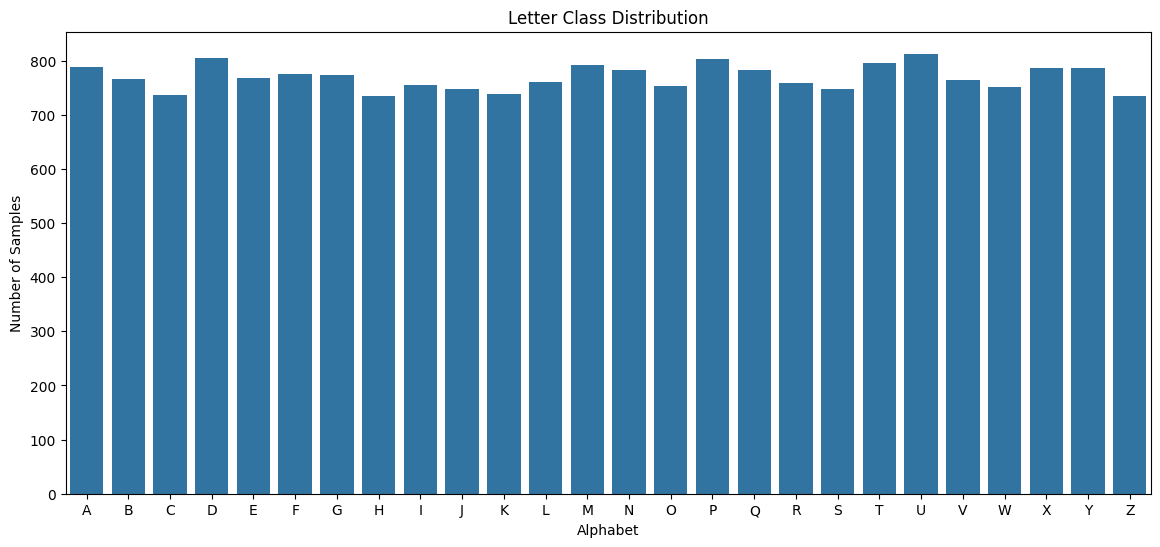

In [19]:
plt.figure(figsize=(14, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.xlabel("Alphabet")
plt.ylabel("Number of Samples")
plt.title("Letter Class Distribution")

plt.show()

## Class Balance

SVM classification can be affected by severe class imbalance.

We will inspect the distribution of all 26 alphabet classes.

If the classes have similar numbers of observations, the dataset
is relatively balanced.

In [20]:
print(
    "Minimum samples:",
    class_counts.min()
)

print(
    "Maximum samples:",
    class_counts.max()
)

print(
    "Difference:",
    class_counts.max() - class_counts.min()
)

Minimum samples: 734
Maximum samples: 813
Difference: 79


# Features and Target

The target is:

`letter`

Everything else will initially be treated as a feature.

X → Numerical letter features

y → Alphabet class

In [21]:
X = df.drop(
    columns=["letter"]
)

y = df["letter"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20000, 16)
y shape: (20000,)


#Inspect Features

In [22]:
X.head()

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


#Feature Statistics

In [23]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
xbox,20000.0,4.02355,1.913212,0.0,3.0,4.0,5.0,15.0
ybox,20000.0,7.03550,3.304555,0.0,5.0,7.0,9.0,15.0
width,20000.0,5.12185,2.014573,0.0,4.0,5.0,6.0,15.0
height,20000.0,5.37245,2.261390,0.0,4.0,6.0,7.0,15.0
onpix,20000.0,3.50585,2.190458,0.0,2.0,3.0,5.0,15.0
xbar,20000.0,6.89760,2.026035,0.0,6.0,7.0,8.0,15.0
ybar,20000.0,7.50045,2.325354,0.0,6.0,7.0,9.0,15.0
x2bar,20000.0,4.62860,2.699968,0.0,3.0,4.0,6.0,15.0
y2bar,20000.0,5.17865,2.380823,0.0,4.0,5.0,7.0,15.0
xybar,20000.0,8.28205,2.488475,0.0,7.0,8.0,10.0,15.0


# Feature Correlation

Let's examine the relationships between the numerical features.

This is useful for understanding the dataset before training.

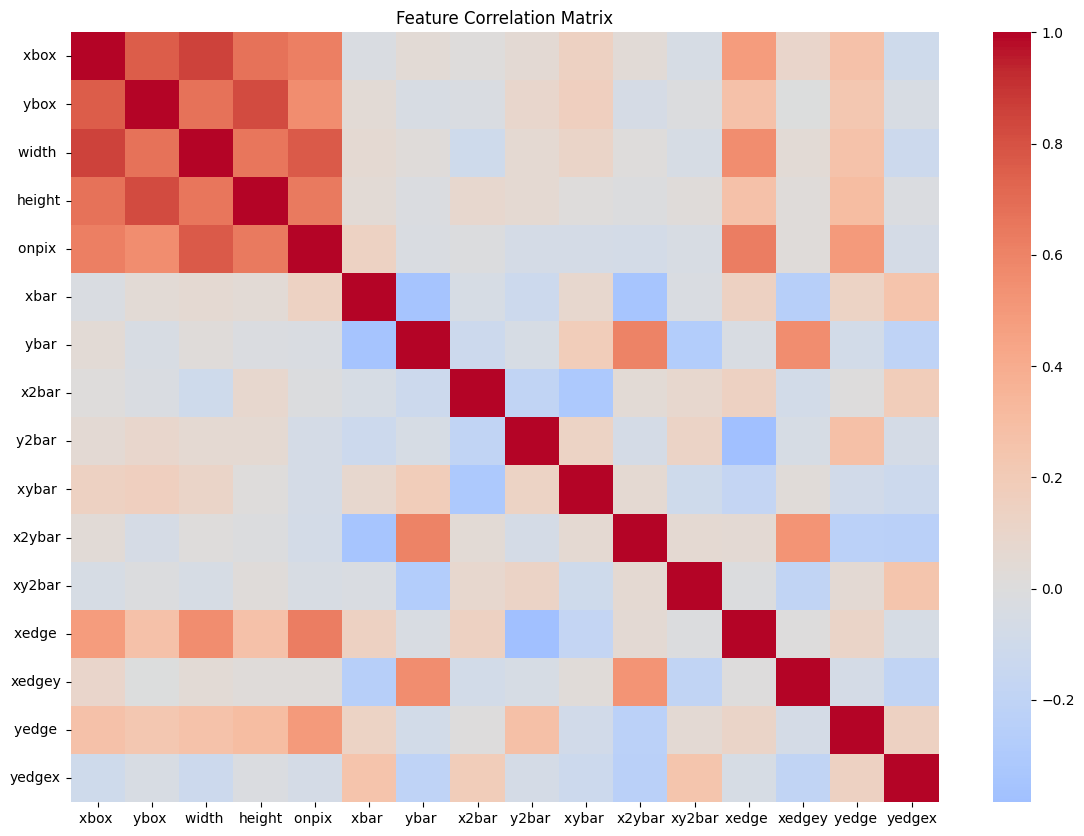

In [24]:
plt.figure(figsize=(14, 10))

correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

#Feature Distributions

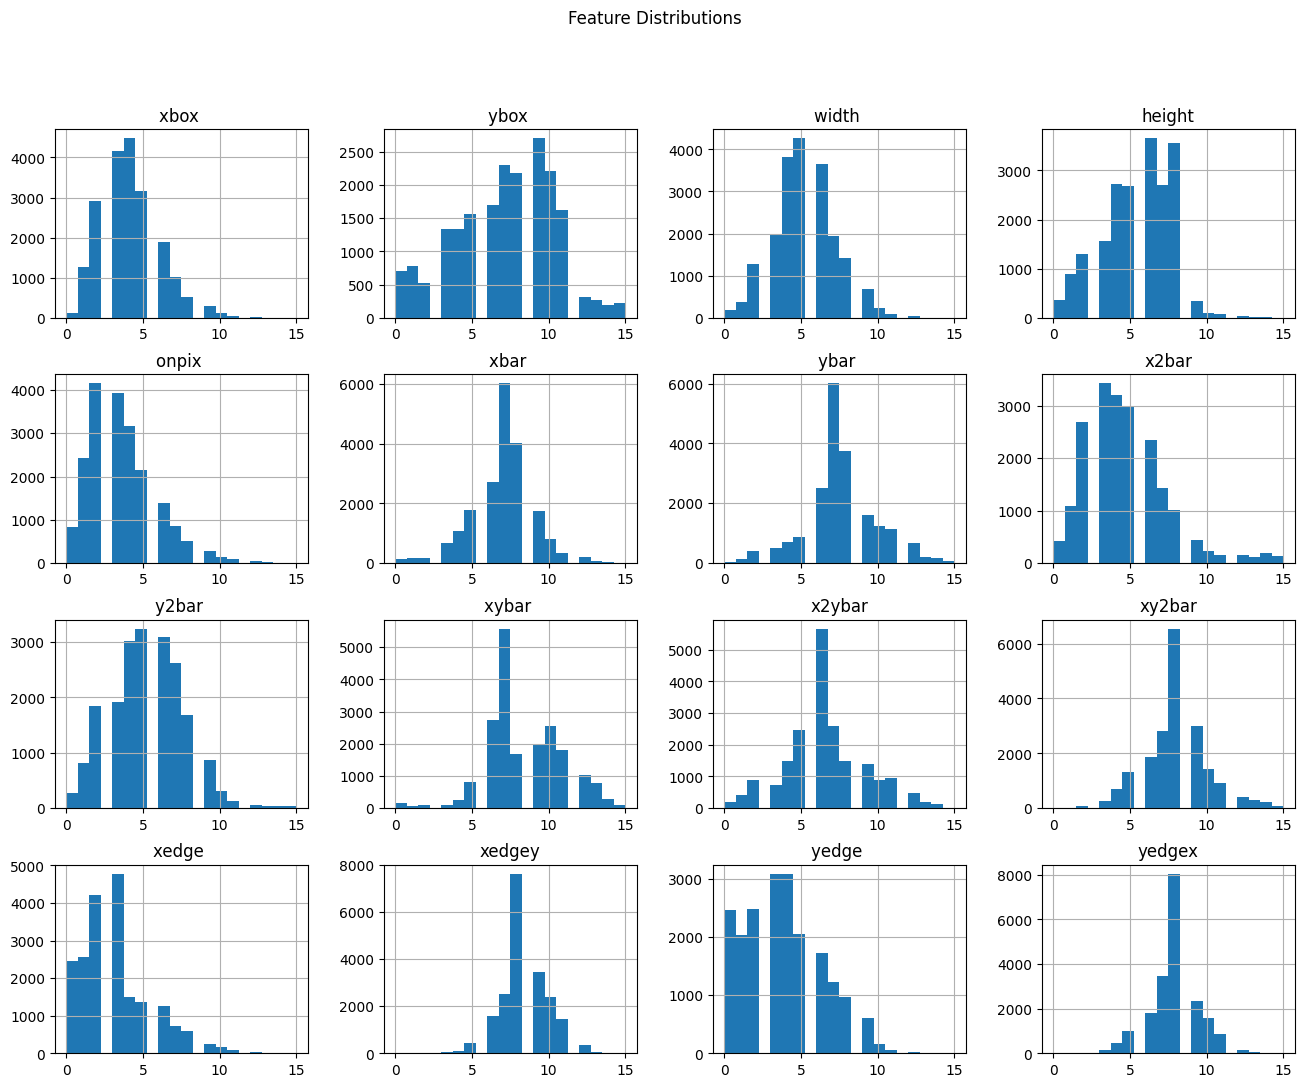

In [25]:
X.hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Feature Distributions"
)

plt.show()

# Train/Test Split

We will use:

80% → Training Data

20% → Testing Data

The model will learn from the training data and will then be evaluated
on unseen test data.

We use `stratify=y` so that all 26 alphabet classes maintain
approximately the same proportions in both sets.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 16000
Testing samples: 4000


#Check Training/Test Classes

In [27]:
print(
    "Training classes:",
    y_train.nunique()
)

print(
    "Testing classes:",
    y_test.nunique()
)

Training classes: 26
Testing classes: 26


# Feature Scaling

SVM is sensitive to the scale of features because its optimization
depends on distances and the geometry of the feature space.

For example:

Feature A → values from 0 to 10

Feature B → values from 0 to 1000

Feature B could have a disproportionately large influence.

We will use StandardScaler:

z = (x - mean) / standard deviation

Important:

The scaler is fitted only on the training data.

#Create StandardScaler

In [28]:
scaler = StandardScaler()

#Scale Training Data

In [29]:
X_train_scaled = scaler.fit_transform(
    X_train
)

print(
    "Training data scaled successfully."
)

Training data scaled successfully.


#Scale Testing Data

In [30]:
X_test_scaled = scaler.transform(
    X_test
)

print(
    "Testing data scaled successfully."
)

Testing data scaled successfully.


#. Verify Scaling

In [31]:
scaled_train_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

print("Mean:")
display(
    scaled_train_df.mean().round(2)
)

print("\nStandard Deviation:")
display(
    scaled_train_df.std().round(2)
)

Mean:


,0
xbox,0.0
ybox,-0.0
width,0.0
height,-0.0
onpix,0.0
xbar,0.0
ybar,0.0
x2bar,-0.0
y2bar,0.0
xybar,0.0



Standard Deviation:


,0
xbox,1.0
ybox,1.0
width,1.0
height,1.0
onpix,1.0
xbar,1.0
ybar,1.0
x2bar,1.0
y2bar,1.0
xybar,1.0


## Linear SVM

A Linear SVM tries to find a hyperplane that separates the classes
while maximizing the margin.

For this dataset, we will first train a linear kernel:

`kernel="linear"`

This gives us a baseline before trying a nonlinear kernel.

In [32]:
linear_svm = SVC(
    kernel="linear",
    C=1.0,
    random_state=42
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


#Make Linear SVM Predictions

In [33]:
y_pred_linear = linear_svm.predict(
    X_test_scaled
)

print(
    y_pred_linear[:20]
)

['R' 'M' 'B' 'P' 'J' 'L' 'P' 'G' 'Z' 'V' 'V' 'B' 'O' 'U' 'X' 'Q' 'L' 'S'
 'B' 'X']


#Linear SVM Accuracy

In [34]:
linear_accuracy = accuracy_score(
    y_test,
    y_pred_linear
)

print(
    f"Linear SVM Accuracy: "
    f"{linear_accuracy:.4f}"
)

Linear SVM Accuracy: 0.8525


# Support Vectors

Support vectors are the training observations that are most important
to defining the SVM decision boundaries.

In scikit-learn, we can inspect them using:

`support_vectors_`

and their counts using:

`n_support_`

In [35]:
print(
    "Total Support Vectors:",
    len(linear_svm.support_)
)

Total Support Vectors: 7163


#Support Vectors Per Class

In [36]:
support_vector_counts = pd.DataFrame({
    "Class": linear_svm.classes_,
    "Support Vectors": linear_svm.n_support_
})

support_vector_counts

,Class,Support Vectors
0,A,129
1,B,342
2,C,239
3,D,253
4,E,310
5,F,298
6,G,462
7,H,493
8,I,213
9,J,227


# RBF Kernel SVM

The linear model assumes that the classes can be separated reasonably
well using linear decision boundaries.

The RBF kernel allows SVM to create nonlinear decision boundaries.

We will use:

`kernel="rbf"`

and initially keep:

`C=1`

`gamma="scale"`

In [37]:
rbf_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

rbf_svm.fit(
    X_train_scaled,
    y_train
)

print(
    "RBF SVM trained successfully."
)

RBF SVM trained successfully.


#Make RBF Predictions

In [38]:
y_pred_rbf = rbf_svm.predict(
    X_test_scaled
)

print(
    y_pred_rbf[:20]
)

['R' 'M' 'B' 'P' 'J' 'L' 'P' 'G' 'Z' 'V' 'V' 'S' 'O' 'U' 'X' 'Q' 'L' 'S'
 'B' 'X']


#RBF Accuracy

In [39]:
rbf_accuracy = accuracy_score(
    y_test,
    y_pred_rbf
)

print(
    f"RBF SVM Accuracy: "
    f"{rbf_accuracy:.4f}"
)

RBF SVM Accuracy: 0.9485


#Compare Linear vs RBF

In [40]:
svm_comparison = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "RBF SVM"
    ],
    "Accuracy": [
        linear_accuracy,
        rbf_accuracy
    ]
})

svm_comparison

,Model,Accuracy
0,Linear SVM,0.8525
1,RBF SVM,0.9485


#Visualize Comparison

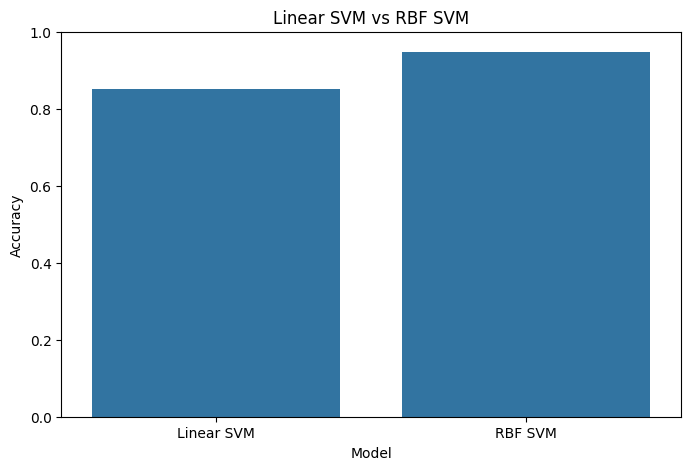

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=svm_comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)

plt.title(
    "Linear SVM vs RBF SVM"
)

plt.ylabel("Accuracy")

plt.show()

#RBF Support Vectors

In [42]:
print(
    "Total RBF Support Vectors:",
    len(rbf_svm.support_)
)

Total RBF Support Vectors: 8550


#. RBF Support Vectors Per Class

In [43]:
rbf_support_counts = pd.DataFrame({
    "Class": rbf_svm.classes_,
    "Support Vectors": rbf_svm.n_support_
})

rbf_support_counts

,Class,Support Vectors
0,A,189
1,B,427
2,C,285
3,D,368
4,E,413
5,F,358
6,G,456
7,H,451
8,I,222
9,J,235


#Inspect Predictions

In [44]:
prediction_results = pd.DataFrame({
    "Actual": y_test.values,
    "Linear SVM": y_pred_linear,
    "RBF SVM": y_pred_rbf
})

prediction_results.head(25)

,Actual,Linear SVM,RBF SVM
0,R,R,R
1,M,M,M
2,B,B,B
3,P,P,P
4,J,J,J
5,L,L,L
6,P,P,P
7,G,G,G
8,Z,Z,Z
9,V,V,V


#Find Predictions Where Models Disagree

In [45]:
model_disagreement = prediction_results[
    prediction_results["Linear SVM"] !=
    prediction_results["RBF SVM"]
]

print(
    "Number of disagreements:",
    len(model_disagreement)
)

model_disagreement.head(20)

Number of disagreements: 506


,Actual,Linear SVM,RBF SVM
11,S,B,S
23,C,C,G
29,Y,V,Y
32,Z,T,Z
36,T,Z,E
44,K,R,K
64,X,X,K
67,S,Z,S
75,U,T,U
80,S,F,S


# Part 1 Complete

We have now:

- Loaded a real-world handwritten alphabet dataset.
- Explored the 26 classes.
- Checked class distribution.
- Separated features and target.
- Performed train/test split.
- Standardized the features.
- Trained a Linear SVM.
- Trained an RBF Kernel SVM.
- Generated predictions.
- Compared Linear and RBF SVM accuracy.
- Examined the number of support vectors.

## Current Workflow

Handwritten Letter Features
↓
Train/Test Split
↓
Feature Scaling
↓
        ┌──────────────┐
        │              │
   Linear SVM      RBF SVM
        │              │
        └──────┬───────┘
               ↓
          Predictions
               ↓
         Model Evaluation

In Part 2, we will evaluate both SVM models in detail and investigate
how `C` and `gamma` affect the model.

We will also visualize the confusion matrix and analyze
which alphabet classes are most difficult to distinguish.

#SVM Evaluation, Hyperparameter Tuning & Visualization

# Linear SVM Evaluation

We will evaluate the Linear SVM using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report

In [46]:
linear_precision = precision_score(
    y_test,
    y_pred_linear,
    average="weighted",
    zero_division=0
)

linear_recall = recall_score(
    y_test,
    y_pred_linear,
    average="weighted",
    zero_division=0
)

linear_f1 = f1_score(
    y_test,
    y_pred_linear,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {linear_accuracy:.4f}")
print(f"Precision: {linear_precision:.4f}")
print(f"Recall   : {linear_recall:.4f}")
print(f"F1 Score : {linear_f1:.4f}")

Accuracy : 0.8525
Precision: 0.8547
Recall   : 0.8525
F1 Score : 0.8528


#Linear SVM Classification Report

In [47]:
print(
    classification_report(
        y_test,
        y_pred_linear,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.92      0.95      0.93       158
           B       0.77      0.88      0.82       153
           C       0.89      0.91      0.90       147
           D       0.83      0.89      0.86       161
           E       0.78      0.84      0.81       154
           F       0.80      0.89      0.84       155
           G       0.77      0.73      0.75       155
           H       0.69      0.67      0.68       147
           I       0.92      0.84      0.88       151
           J       0.89      0.88      0.89       149
           K       0.80      0.80      0.80       148
           L       0.89      0.91      0.90       152
           M       0.95      0.92      0.94       158
           N       0.94      0.89      0.92       157
           O       0.86      0.79      0.83       150
           P       0.93      0.84      0.89       161
           Q       0.83      0.80      0.82       157
           R       0.74    

#Evaluate RBF SVM

In [48]:
rbf_precision = precision_score(
    y_test,
    y_pred_rbf,
    average="weighted",
    zero_division=0
)

rbf_recall = recall_score(
    y_test,
    y_pred_rbf,
    average="weighted",
    zero_division=0
)

rbf_f1 = f1_score(
    y_test,
    y_pred_rbf,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {rbf_accuracy:.4f}")
print(f"Precision: {rbf_precision:.4f}")
print(f"Recall   : {rbf_recall:.4f}")
print(f"F1 Score : {rbf_f1:.4f}")

Accuracy : 0.9485
Precision: 0.9495
Recall   : 0.9485
F1 Score : 0.9486


#RBF Classification Report

In [49]:
print(
    classification_report(
        y_test,
        y_pred_rbf,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.97      0.96      0.96       158
           B       0.87      0.95      0.91       153
           C       0.97      0.97      0.97       147
           D       0.90      0.96      0.93       161
           E       0.92      0.95      0.94       154
           F       0.94      0.94      0.94       155
           G       0.93      0.97      0.95       155
           H       0.86      0.86      0.86       147
           I       0.98      0.90      0.94       151
           J       0.94      0.97      0.95       149
           K       0.94      0.95      0.95       148
           L       0.99      0.93      0.96       152
           M       0.99      0.95      0.97       158
           N       0.95      0.94      0.94       157
           O       0.93      0.93      0.93       150
           P       0.99      0.93      0.96       161
           Q       0.97      0.96      0.96       157
           R       0.89    

#Compare Both Models


In [50]:
svm_metrics = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "RBF SVM"
    ],
    "Accuracy": [
        linear_accuracy,
        rbf_accuracy
    ],
    "Precision": [
        linear_precision,
        rbf_precision
    ],
    "Recall": [
        linear_recall,
        rbf_recall
    ],
    "F1 Score": [
        linear_f1,
        rbf_f1
    ]
})

svm_metrics

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.8525,0.85475,0.8525,0.852776
1,RBF SVM,0.9485,0.94950,0.9485,0.948636


#Visualize Model Comparison

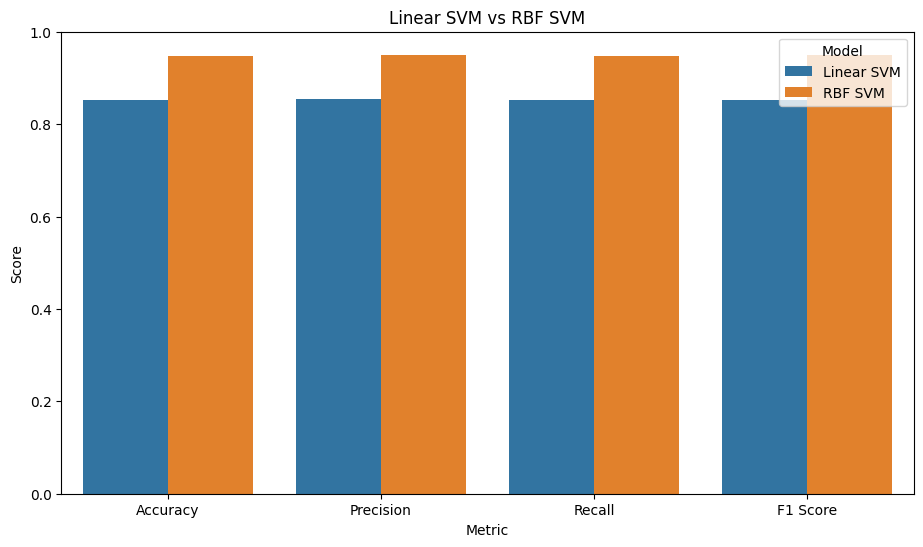

In [51]:
metrics_long = svm_metrics.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=metrics_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.ylim(0, 1)
plt.title("Linear SVM vs RBF SVM")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.show()

#Confusion Matrix — RBF SVM

# Confusion Matrix

Because this is a 26-class classification problem, the confusion matrix
contains 26 rows and 26 columns.

The diagonal represents correctly classified letters.

Off-diagonal values represent incorrect classifications.

For example:

Actual A → Predicted A

is a correct prediction.

Actual A → Predicted B

is a misclassification.

In [52]:
cm_rbf = confusion_matrix(
    y_test,
    y_pred_rbf,
    labels=rbf_svm.classes_
)

print(cm_rbf)

[[151   0   2   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   1   0   0   0   3   0]
 [  0 145   0   0   1   0   0   2   0   0   0   0   0   0   0   0   0   1
    3   0   1   0   0   0   0   0]
 [  0   0 142   0   2   0   1   0   0   0   0   0   0   0   1   0   0   0
    0   0   0   0   1   0   0   0]
 [  0   3   0 155   0   0   0   0   0   0   0   0   0   1   0   0   0   1
    0   0   0   0   0   1   0   0]
 [  0   1   1   0 147   0   2   0   0   0   0   0   0   0   0   0   0   1
    0   0   0   0   0   0   0   2]
 [  0   1   0   0   1 145   0   2   0   0   0   0   0   2   0   1   0   0
    1   2   0   0   0   0   0   0]
 [  0   1   0   1   1   0 150   0   0   0   0   0   0   0   0   0   1   1
    0   0   0   0   0   0   0   0]
 [  0   1   0   7   0   0   1 127   0   0   1   0   0   1   0   0   1   7
    0   0   1   0   0   0   0   0]
 [  1   0   0   0   0   2   0   0 136   8   0   0   0   0   0   0   0   0
    1   0   0   0   0   3   0   0]
 [  1   0   0   0  

#Visualize the 26 × 26 Confusion Matrix

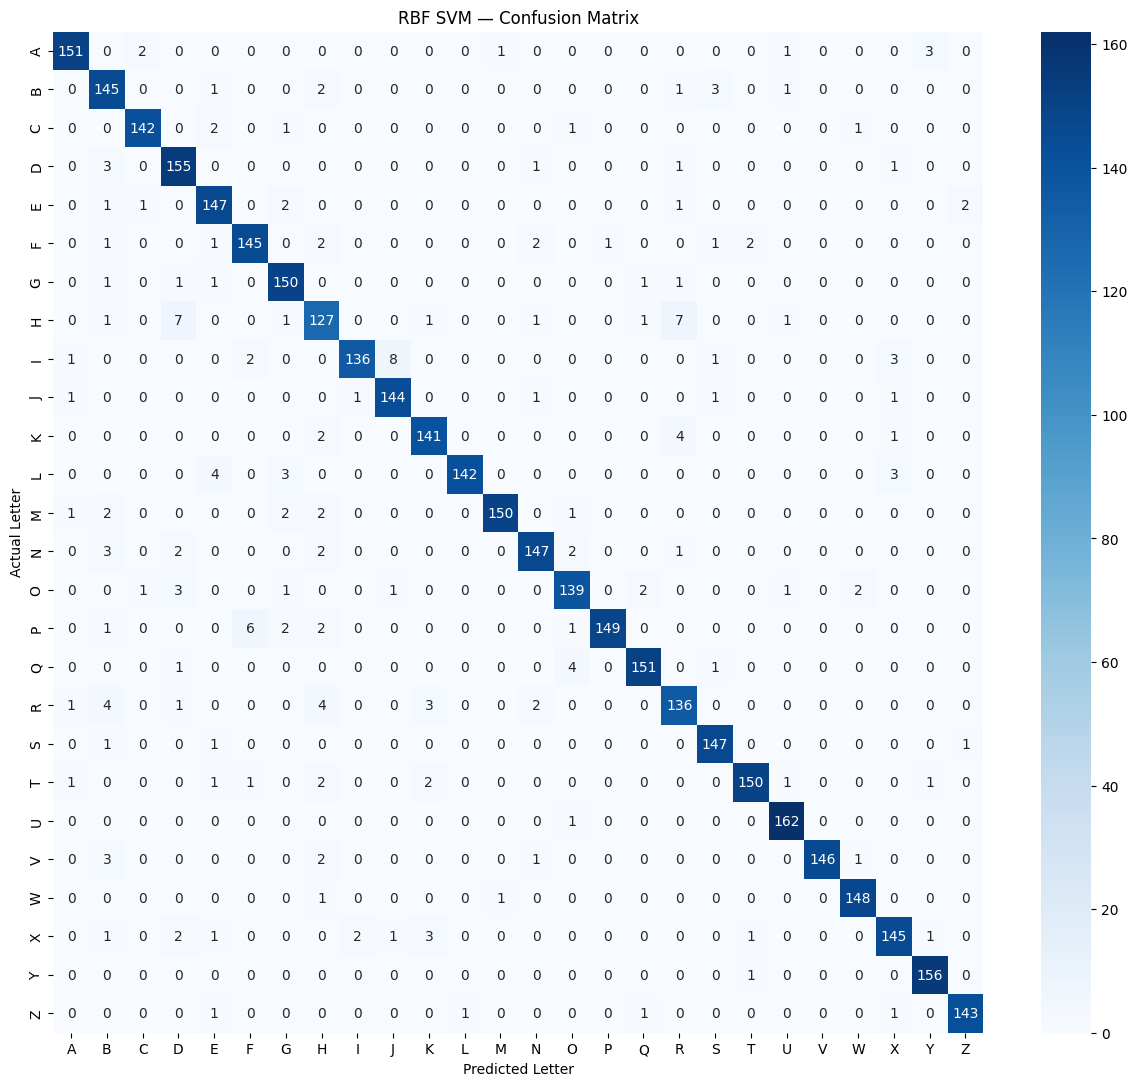

In [53]:
plt.figure(figsize=(15, 13))

sns.heatmap(
    cm_rbf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rbf_svm.classes_,
    yticklabels=rbf_svm.classes_
)

plt.xlabel("Predicted Letter")
plt.ylabel("Actual Letter")
plt.title("RBF SVM — Confusion Matrix")

plt.show()

#Find Most Commonly Confused Letters

In [54]:
cm_errors = cm_rbf.copy()

np.fill_diagonal(
    cm_errors,
    0
)

confusion_pairs = []

classes = rbf_svm.classes_

for i in range(len(classes)):
    for j in range(len(classes)):

        if cm_errors[i, j] > 0:

            confusion_pairs.append({
                "Actual": classes[i],
                "Predicted": classes[j],
                "Errors": cm_errors[i, j]
            })

confusion_pairs_df = pd.DataFrame(
    confusion_pairs
).sort_values(
    "Errors",
    ascending=False
)

confusion_pairs_df.head(15)

,Actual,Predicted,Errors
44,I,J,8
35,H,D,7
40,H,R,7
76,P,F,6
53,K,R,4
55,L,E,4
86,R,H,4
84,R,B,4
81,Q,O,4
56,L,G,3


# Per-Class Performance

Overall accuracy can hide differences between individual letters.

We will calculate the accuracy/recall for each alphabet class.

This allows us to identify:

- Easily recognized letters
- Difficult letters
- Frequently confused classes

In [55]:
report_dict = classification_report(
    y_test,
    y_pred_rbf,
    output_dict=True,
    zero_division=0
)

class_performance = pd.DataFrame(
    report_dict
).T

class_performance = class_performance.loc[
    [c for c in rbf_svm.classes_]
]

class_performance

,precision,recall,f1-score,support
A,0.967949,0.955696,0.961783,158.0
B,0.868263,0.947712,0.906250,153.0
C,0.972603,0.965986,0.969283,147.0
D,0.901163,0.962733,0.930931,161.0
E,0.918750,0.954545,0.936306,154.0
F,0.941558,0.935484,0.938511,155.0
G,0.925926,0.967742,0.946372,155.0
H,0.858108,0.863946,0.861017,147.0
I,0.978417,0.900662,0.937931,151.0
J,0.935065,0.966443,0.950495,149.0


#Visualize Per-Class Recall

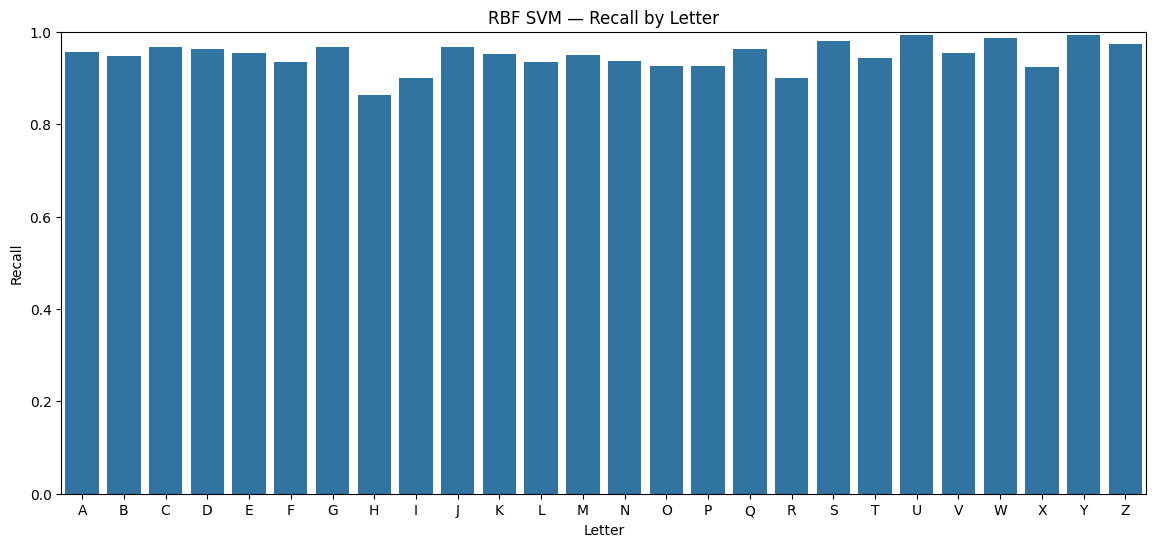

In [56]:
plt.figure(figsize=(14, 6))

sns.barplot(
    x=class_performance.index,
    y=class_performance["recall"]
)

plt.ylim(0, 1)

plt.xlabel("Letter")
plt.ylabel("Recall")
plt.title("RBF SVM — Recall by Letter")

plt.show()

#Find Best and Worst Classes

In [57]:
best_classes = (
    class_performance["recall"]
    .sort_values(ascending=False)
    .head(5)
)

worst_classes = (
    class_performance["recall"]
    .sort_values()
    .head(5)
)

print("Best performing classes:")
display(best_classes)

print("\nWorst performing classes:")
display(worst_classes)

Best performing classes:


,recall
U,0.993865
Y,0.993631
W,0.986667
S,0.980000
Z,0.972789



Worst performing classes:


,recall
H,0.863946
I,0.900662
R,0.900662
X,0.923567
P,0.925466


# SVM Hyperparameter — C

`C` controls the penalty for classification errors.

A simplified intuition:

### Small C

- Allows more classification errors
- Produces a wider margin
- Can create a simpler model
- May underfit

### Large C

- Penalizes errors more strongly
- Tries harder to classify training examples correctly
- Can produce a more complex boundary
- May overfit

We will test multiple values of C.

#Test Different C Values

In [58]:
C_values = [
    0.1,
    1,
    10,
    100
]

C_results = []

for c in C_values:

    model = SVC(
        kernel="rbf",
        C=c,
        gamma="scale",
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    train_pred = model.predict(
        X_train_scaled
    )

    test_pred = model.predict(
        X_test_scaled
    )

    train_acc = accuracy_score(
        y_train,
        train_pred
    )

    test_acc = accuracy_score(
        y_test,
        test_pred
    )

    C_results.append({
        "C": c,
        "Training Accuracy": train_acc,
        "Testing Accuracy": test_acc
    })

C_results_df = pd.DataFrame(
    C_results
)

C_results_df

,C,Training Accuracy,Testing Accuracy
0,0.1,0.853500,0.84550
1,1.0,0.958750,0.94850
2,10.0,0.993062,0.97475
3,100.0,0.999750,0.97075


#Visualize C vs Accuracy

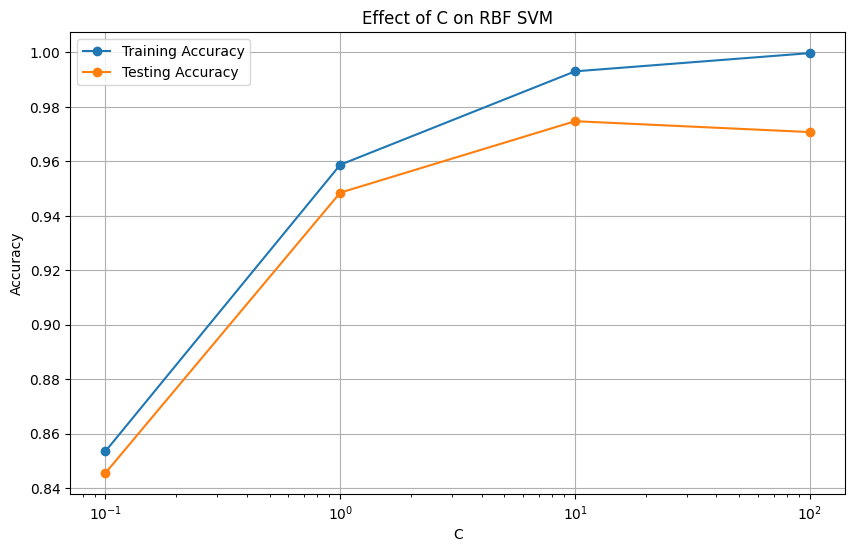

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(
    C_results_df["C"],
    C_results_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    C_results_df["C"],
    C_results_df["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Effect of C on RBF SVM")

plt.legend()
plt.grid(True)

plt.show()

# SVM Hyperparameter — Gamma

`gamma` controls how far the influence of a training point extends
when using the RBF kernel.

### Low Gamma

A point has influence over a larger region.

→ Smoother decision boundary

→ Simpler model

### High Gamma

A point has influence over a smaller region.

→ More complex/local decision boundary

→ Higher risk of overfitting

We will test different gamma values.

#Test Different Gamma Values

In [60]:
gamma_values = [
    0.001,
    0.01,
    0.1,
    1
]

gamma_results = []

for gamma in gamma_values:

    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma=gamma,
        random_state=42
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    train_pred = model.predict(
        X_train_scaled
    )

    test_pred = model.predict(
        X_test_scaled
    )

    train_acc = accuracy_score(
        y_train,
        train_pred
    )

    test_acc = accuracy_score(
        y_test,
        test_pred
    )

    gamma_results.append({
        "Gamma": gamma,
        "Training Accuracy": train_acc,
        "Testing Accuracy": test_acc
    })

gamma_results_df = pd.DataFrame(
    gamma_results
)

gamma_results_df

,Gamma,Training Accuracy,Testing Accuracy
0,0.001,0.713437,0.71675
1,0.010,0.858313,0.85275
2,0.100,0.972812,0.96250
3,1.000,0.999750,0.94750


#Visualize Gamma vs Accuracy

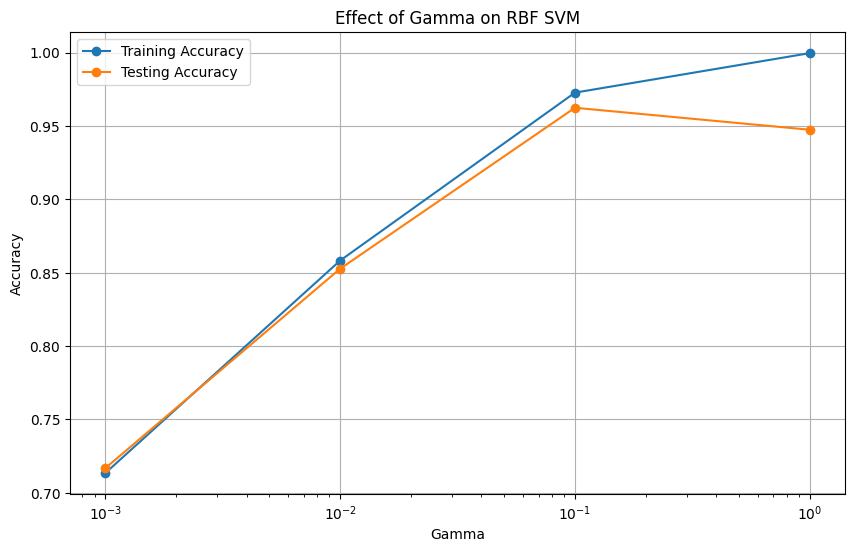

In [61]:
plt.figure(figsize=(10, 6))

plt.plot(
    gamma_results_df["Gamma"],
    gamma_results_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    gamma_results_df["Gamma"],
    gamma_results_df["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.xscale("log")

plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.title("Effect of Gamma on RBF SVM")

plt.legend()
plt.grid(True)

plt.show()

#Grid Search for Best Parameters

# Hyperparameter Tuning

We will search through different combinations of:

- C
- gamma

The combination that performs best during cross-validation will be selected.

We will use `GridSearchCV` on the training data.

The test set remains untouched until the final evaluation.

In [62]:
from sklearn.model_selection import GridSearchCV

#Define Parameter Grid

In [63]:
param_grid = {
    "C": [
        0.1,
        1,
        10,
        100
    ],
    "gamma": [
        "scale",
        0.001,
        0.01,
        0.1
    ]
}

param_grid

{'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.001, 0.01, 0.1]}

#Create Grid Search

In [64]:
grid_search = GridSearchCV(
    estimator=SVC(
        kernel="rbf",
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

#Train Grid Search

In [ ]:
grid_search.fit(
    X_train_scaled,
    y_train
)

print("Grid Search completed.")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Grid Search completed.


#Best Parameters

In [ ]:
print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

Best Parameters:
{'C': 10, 'gamma': 0.1}


#Best Cross-Validation Score

In [ ]:
print(
    "Best Cross-Validation Accuracy:",
    grid_search.best_score_
)

Best Cross-Validation Accuracy: 0.9671247614768199


#Get Best Model

In [ ]:
best_svm = grid_search.best_estimator_

print(best_svm)

SVC(C=10, gamma=0.1, random_state=42)


#Final Test Prediction

In [ ]:
y_pred_best = best_svm.predict(
    X_test_scaled
)

best_test_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print(
    f"Final Test Accuracy: "
    f"{best_test_accuracy:.4f}"
)

Final Test Accuracy: 0.9772


#Final Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_best,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           A       0.99      1.00      1.00       158
           B       0.95      0.95      0.95       153
           C       0.98      0.98      0.98       147
           D       0.95      0.97      0.96       161
           E       0.95      0.97      0.96       154
           F       0.98      0.98      0.98       155
           G       0.97      0.97      0.97       155
           H       0.93      0.95      0.94       147
           I       0.97      0.95      0.96       151
           J       0.94      0.97      0.95       149
           K       0.95      0.97      0.96       148
           L       0.99      0.98      0.99       152
           M       1.00      0.99      0.99       158
           N       0.99      0.98      0.98       157
           O       0.99      0.97      0.98       150
           P       0.99      0.98      0.98       161
           Q       1.00      1.00      1.00       157
           R       0.97    

#Final Confusion Matrix

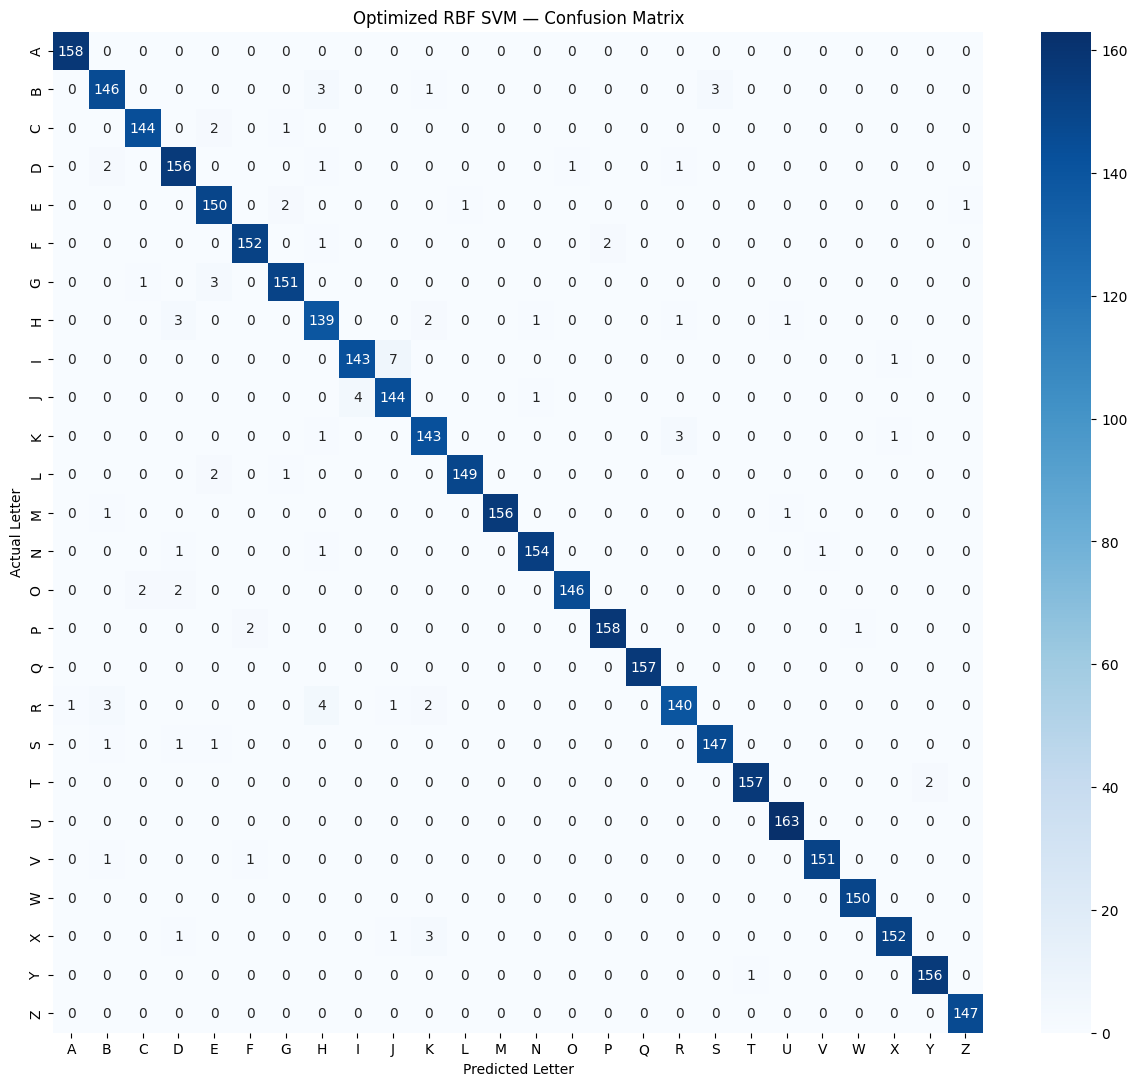

In [ ]:
best_cm = confusion_matrix(
    y_test,
    y_pred_best,
    labels=best_svm.classes_
)

plt.figure(figsize=(15, 13))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_svm.classes_,
    yticklabels=best_svm.classes_
)

plt.xlabel("Predicted Letter")
plt.ylabel("Actual Letter")
plt.title("Optimized RBF SVM — Confusion Matrix")

plt.show()

#Final SVM Comparison

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Initial RBF SVM",
        "Optimized RBF SVM"
    ],
    "Accuracy": [
        linear_accuracy,
        rbf_accuracy,
        best_test_accuracy
    ]
})

final_comparison

,Model,Accuracy
0,Linear SVM,0.85250
1,Initial RBF SVM,0.94850
2,Optimized RBF SVM,0.97725


#Visualize Final Comparison

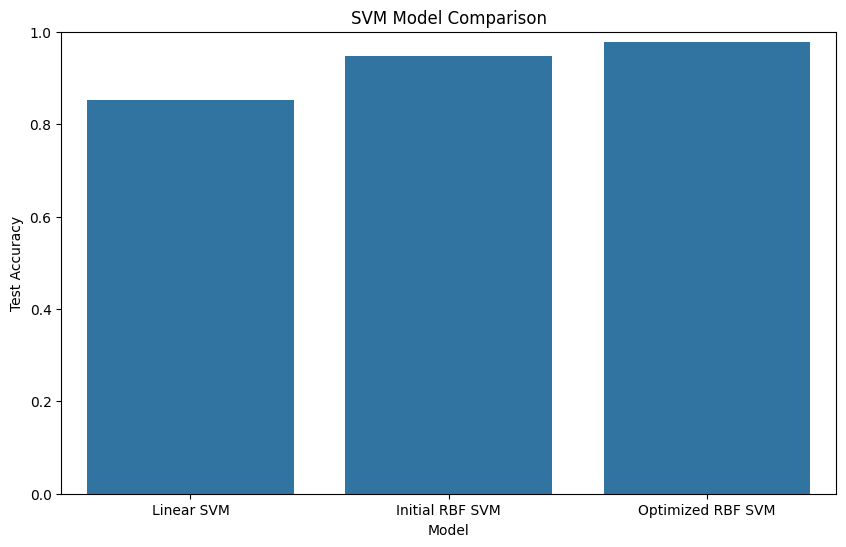

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=final_comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)

plt.title(
    "SVM Model Comparison"
)

plt.ylabel("Test Accuracy")

plt.show()

#Final Support Vector Count

In [ ]:
print(
    "Total Support Vectors:",
    len(best_svm.support_)
)

Total Support Vectors: 7153


In [ ]:
print(
    "Total Support Vectors:",
    len(best_svm.support_)
)

Total Support Vectors: 7153


#Prediction Example

In [ ]:
sample_index = 0

sample = X_test.iloc[
    [sample_index]
]

actual_letter = y_test.iloc[
    sample_index
]

predicted_letter = best_svm.predict(
    scaler.transform(sample)
)[0]

print(
    "Actual Letter   :",
    actual_letter
)

print(
    "Predicted Letter:",
    predicted_letter
)

Actual Letter   : R
Predicted Letter: R


#Test Multiple Letters

In [ ]:
sample_data = X_test.iloc[:20]

sample_actual = y_test.iloc[:20].values

sample_predicted = best_svm.predict(
    scaler.transform(sample_data)
)

sample_results = pd.DataFrame({
    "Actual": sample_actual,
    "Predicted": sample_predicted
})

sample_results

,Actual,Predicted
0,R,R
1,M,M
2,B,B
3,P,P
4,J,J
5,L,L
6,P,P
7,G,G
8,Z,Z
9,V,V


#Prediction Accuracy on Sample

In [ ]:
sample_accuracy = accuracy_score(
    sample_results["Actual"],
    sample_results["Predicted"]
)

print(
    f"Sample Accuracy: {sample_accuracy:.2%}"
)

Sample Accuracy: 100.00%


#Final Model Summary

In [ ]:
final_precision = precision_score(
    y_test,
    y_pred_best,
    average="weighted",
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred_best,
    average="weighted",
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_pred_best,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("FINAL SVM MODEL")
print("=" * 60)

print("Kernel:", best_svm.kernel)
print("C:", best_svm.C)
print("Gamma:", best_svm.gamma)

print("\nPerformance:")
print(f"Accuracy : {best_test_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")

print(
    "\nSupport Vectors:",
    len(best_svm.support_)
)

print("=" * 60)

FINAL SVM MODEL
Kernel: rbf
C: 10
Gamma: 0.1

Performance:
Accuracy : 0.9772
Precision: 0.9774
Recall   : 0.9772
F1 Score : 0.9773

Support Vectors: 7153


# Interpretation

We trained two different types of SVM:

## Linear SVM

Uses a linear decision boundary.

It provides a strong baseline and is computationally simpler.

## RBF SVM

Uses the Radial Basis Function kernel to model nonlinear relationships.

It introduces two important hyperparameters:

### C

Controls the penalty for classification errors.

### Gamma

Controls the influence of individual training points.

We tested different values and then used GridSearchCV to select
a promising combination based on cross-validation on the training data.

The final model was then evaluated on the untouched test dataset.

## Multiclass Classification

Although SVM is often introduced using two classes, `SVC` can handle
multiclass classification.

Our problem contains:

A, B, C, ..., Z

Therefore:

**26 Classes → Multiclass SVM → One Predicted Letter**

# SVM Module Complete

We have now completed the complete SVM workflow:

Dataset
↓
Kaggle API
↓
Data Exploration
↓
Feature Preparation
↓
Train/Test Split
↓
Feature Scaling
↓
Linear SVM
↓
RBF Kernel SVM
↓
Predictions
↓
Evaluation
↓
Confusion Matrix
↓
C & Gamma Analysis
↓
Grid Search
↓
Optimized SVM
↓
Final Testing

## Key SVM Concepts Covered

- Support Vector
- Decision Boundary
- Margin
- Linear Kernel
- RBF Kernel
- C
- Gamma
- Feature Scaling
- Multiclass Classification
- Hyperparameter Tuning
- Confusion Matrix
- Precision
- Recall
- F1 Score
- Model Comparison

The final model can now recognize one of the 26 English alphabet classes
from the numerical features extracted from a handwritten letter.